In [29]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# Import all necessary libraries for data manipulation, visualization and deep learning.

In [30]:
BASE_DIR = Path.cwd()
path_db = BASE_DIR / "BreaKHis_v1" / "histology_slides" / "breast"


def packup_details(f):
    p = Path(f)

    # only filename, cross-platform safe
    filename = p.name                          # SOB_B_A-14-22549G-100-001.png
    stem = p.stem                             # SOB_B_A-14-22549G-100-001

    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {filename}")

    example = parts[0]                        # SOB
    is_malign = 1 if parts[1] == "M" else 0   # M -> malignant, B -> benign

    names = parts[2].split("-")
    if len(names) < 5:
        raise ValueError(f"Unexpected tumor name format: {filename}")

    class_tumor = names[0]
    year = int(names[1]) + 2000
    patient_id = names[2]
    zoom = int(names[3])
    file_id = names[4]

    return {
        "patient_id": patient_id,
        "file_id": file_id,
        "example": example,
        "class": class_tumor,
        "year": year,
        "zoom": zoom,
        "file_path": str(p),
        "is_malign": is_malign,
    }


def print_file_details(f):
    p = Path(f)
    filename = p.name
    stem = p.stem

    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {filename}")

    print("Type of example:", parts[0])
    print("State:", parts[1], "(", 1 if parts[1] == "M" else 0, ")")

    nm = parts[2].split("-")
    if len(nm) < 5:
        raise ValueError(f"Unexpected tumor name format: {filename}")

    print("Class:", nm[0])
    print("Year:", nm[1])
    print("Patient ID:", nm[2])
    print("Zoom:", nm[3])
    print("File ID:", nm[4])


def prepare_data_table(rootpath=path_db) -> pd.DataFrame:
    rootpath = Path(rootpath)

    # cross-platform recursive PNG search
    files = list(rootpath.rglob("*.png"))

    if not files:
        raise FileNotFoundError(f"No PNG files found under: {rootpath}")

    datas = []
    bad_files = []

    for f in files:
        try:
            datas.append(packup_details(f))
        except Exception as e:
            bad_files.append((str(f), str(e)))

    df = pd.DataFrame(datas)

    print("DataFrame shape:", df.shape)
    print("DataFrame columns:", df.columns.tolist())
    print("Parsed files:", len(datas))
    print("Failed files:", len(bad_files))

    if bad_files:
        print("\nFirst 10 problematic files:")
        for fp, err in bad_files[:10]:
            print(fp, "->", err)

    return df

In [31]:
# Prepare the data table using the custom function from bk_tools and display its information.

df = prepare_data_table()
df.info()

DataFrame shape: (7909, 8)
DataFrame columns: ['patient_id', 'file_id', 'example', 'class', 'year', 'zoom', 'file_path', 'is_malign']
Parsed files: 7909
Failed files: 0
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


In [32]:
def set_seeds(seed: int = 42):
    SEED = 42
    os.environ["PYTHONHASHSEED"] = str(SEED)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def prepare_data_splitting(df: pd.DataFrame, chosen_zoom: int = 200, test_val_size: int = 0.2 ):   
    set_seeds() # Set seeds for reproducibility

    # Choose the zoom level to work with 
    df_zoom = df[df["zoom"] == chosen_zoom].copy()
    # Get unique patients and their malignancy status for stratification
    unique_patients = df_zoom[["patient_id","is_malign"]].drop_duplicates()
    # Train - Val/Test split    
    train_p, tmp_p_ids = train_test_split(
        unique_patients['patient_id'], 
        test_size=test_val_size, 
        stratify=unique_patients['is_malign'],
        random_state=42
    )
    # Val/Test split
    tmp_df = unique_patients[unique_patients['patient_id'].isin(tmp_p_ids)]
    val_p, test_p = train_test_split(
        tmp_df['patient_id'],
        test_size=0.5,
        stratify=tmp_df['is_malign'],
        random_state=42
    )
    # Create DataFrames for each split
    train_df = df_zoom[df_zoom['patient_id'].isin(train_p)].reset_index(drop=True)
    val_df = df_zoom[df_zoom['patient_id'].isin(val_p)].reset_index(drop=True)
    test_df = df_zoom[df_zoom['patient_id'].isin(test_p)].reset_index(drop=True)

    # Filter the DataFrames for the chosen zoom level (if not already done)
    train_df_200 = train_df[train_df['zoom'] == chosen_zoom]
    val_df_200 = val_df[val_df['zoom'] == chosen_zoom]
    test_df_200 = test_df[test_df['zoom'] == chosen_zoom]

    # Check for patient ID overlaps to ensure no data leakage
    print("\nPatient split check:")
    print(train_df["patient_id"].nunique(), val_df["patient_id"].nunique(), test_df["patient_id"].nunique())
    print(set(train_df["patient_id"]) & set(val_df["patient_id"]))
    print(set(train_df["patient_id"]) & set(test_df["patient_id"]))
    print(set(val_df["patient_id"]) & set(test_df["patient_id"]))

    return train_df_200, val_df_200, test_df_200



In [33]:
# Prepare the data splitting for the chosen zoom level (200) and display the class distribution in the validation set.
train_df_200, val_df_200, test_df_200 = prepare_data_splitting(df=df, chosen_zoom=200, test_val_size=0.2)
print(val_df_200["is_malign"].value_counts())



Patient split check:
64 8 9
set()
set()
set()
is_malign
1    155
0     33
Name: count, dtype: int64


In [34]:
# Define the data augmentation for the training set and the preprocessing for the validation and test sets using ImageDataGenerator.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [35]:
# Create the data generators for training, validation, and testing using flow_from_dataframe.
train_generate = train_datagen.flow_from_dataframe(
    train_df_200,
    x_col="file_path",
    y_col="is_malign",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=True
)

val_generate = test_val_datagen.flow_from_dataframe(
    val_df_200,
    x_col="file_path",
    y_col="is_malign",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=False
)

test_generate = test_val_datagen.flow_from_dataframe(
    test_df_200,
    x_col="file_path",
    y_col="is_malign",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=False
)

Found 1628 validated image filenames.
Found 188 validated image filenames.
Found 197 validated image filenames.


In [36]:
# Define the model architecture using a pre-trained ResNet50 as the base and adding custom layers on top. Compile the model with an appropriate loss function, optimizer, and evaluation metrics.
def create_model():
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False, 
        input_shape=(224, 224, 3)
    )

    base_model.trainable = True

    #for layer in base_model.layers[:-30]:
        #layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    
    loss= tf.keras.losses.BinaryFocalCrossentropy(
        gamma=1.5,
        apply_class_balancing=False
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss,
        metrics=[
            'accuracy', 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [37]:
# Create the model and print its summary to verify the architecture and the number of parameters.
my_model = create_model()
my_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,953 (90.02 MB)

 Trainable params: 23,487,617 (89.60 MB)

 Non-trainable params: 110,336 (431.00 KB)

In [38]:
# Set up callbacks for learning rate reduction, early stopping, and model checkpointing during training.

callbacks = [
    # Reduces the learning rate by multiplying with 0.2, if validation loss not improving in 2 epochs. Minimum learning rate can go down to 1e-7
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    # If validation recall does not improve for 4 epochs, stop training and restore the best weights.
    EarlyStopping(
        monitor='val_recall', 
        patience=4,             
        mode='max', 
        restore_best_weights=True
    ),
    # Save the best model based on validation AUC during training.
    ModelCheckpoint(
        'models/best_model_binary_classification.keras',
        monitor='val_auc', 
        save_best_only=True, 
        mode='max'
    )
]

# Calculate class weights to handle class imbalance in the training data.
y_train = train_df_200["is_malign"].values.astype(int)

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

# Train the model using the fit method with the training and validation generators, class weights, and callbacks.

history = my_model.fit(
    train_generate,
    validation_data=val_generate,
    class_weight=class_weight,
    epochs=30,              
    callbacks=callbacks,
    verbose=1               
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 680ms/step - accuracy: 0.7273 - auc: 0.8260 - loss: 0.2732 - precision: 0.8704 - recall: 0.7062 - val_accuracy: 0.8936 - val_auc: 1.0000 - val_loss: 0.0961 - val_precision: 0.8857 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 633ms/step - accuracy: 0.8372 - auc: 0.9228 - loss: 0.1437 - precision: 0.9266 - recall: 0.8275 - val_accuracy: 0.9309 - val_auc: 0.9852 - val_loss: 0.0807 - val_precision: 0.9226 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 664ms/step - accuracy: 0.8986 - auc: 0.9618 - loss: 0.0968 - precision: 0.9523 - recall: 0.8967 - val_accuracy: 0.9202 - val_auc: 0.9307 - val_loss: 0.2933 - val_precision: 0.9118 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8925 - auc: 0.9637 - loss: 0.0948 - precision: 0.9510 - recall: 0.8886 - val_accuracy: 0.9362 - val_auc: 0.9761 - val_loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 794ms/step

Test Classification Report
               precision    recall  f1-score   support

   Benign (0)       1.00      0.08      0.15        75
Malignant (1)       0.64      1.00      0.78       122

     accuracy                           0.65       197
    macro avg       0.82      0.54      0.46       197
 weighted avg       0.78      0.65      0.54       197



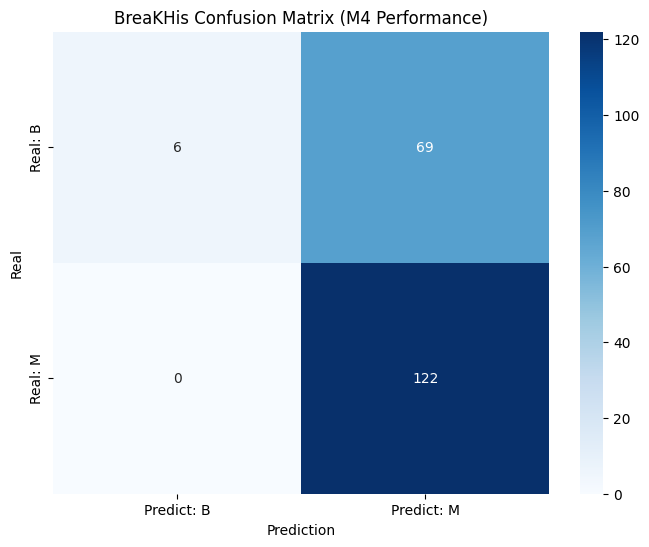

In [39]:
# Evaluate the model on the test set and print the classification report and confusion matrix.
predictions = my_model.predict(test_generate)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_df_200['is_malign'].values

print("\n" + "="*30)
print("Test Classification Report")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predict: B', 'Predict: M'], 
            yticklabels=['Real: B', 'Real: M'])
plt.title('BreaKHis Confusion Matrix (M4 Performance)')
plt.ylabel('Real')
plt.xlabel('Prediction')
plt.show()

In [40]:
# Print the minimum, maximum, and mean values of the predictions to understand the range of predicted probabilities.
print(predictions.min(), predictions.max(), predictions.mean())

0.15356258 0.9974904 0.8925473


In [41]:
# Print the 10th, 25th, 50th, 75th, and 90th percentiles of the predictions to understand the distribution of predicted probabilities.
print(np.percentile(predictions, [10, 25, 50, 75, 90]))

[0.70380104 0.83728546 0.97846383 0.99161035 0.99415781]


In [42]:
# Analyze the effect of different thresholds on the confusion matrix, precision, and recall by iterating through a range of threshold values and printing the corresponding metrics.
for thr in [0.15, 0.2, 0.25, 0.3, 0.35,0.4, 0.45, 0.5]:
    pred = (predictions >= thr).astype(int)
    
    from sklearn.metrics import confusion_matrix, precision_score, recall_score
    
    print(f"\nThreshold: {thr}")
    print(confusion_matrix(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall:", recall_score(y_true, pred, zero_division=0))


Threshold: 0.15
[[  0  75]
 [  0 122]]
Precision: 0.6192893401015228
Recall: 1.0

Threshold: 0.2
[[  1  74]
 [  0 122]]
Precision: 0.6224489795918368
Recall: 1.0

Threshold: 0.25
[[  2  73]
 [  0 122]]
Precision: 0.6256410256410256
Recall: 1.0

Threshold: 0.3
[[  3  72]
 [  0 122]]
Precision: 0.6288659793814433
Recall: 1.0

Threshold: 0.35
[[  4  71]
 [  0 122]]
Precision: 0.6321243523316062
Recall: 1.0

Threshold: 0.4
[[  6  69]
 [  0 122]]
Precision: 0.6387434554973822
Recall: 1.0

Threshold: 0.45
[[  6  69]
 [  0 122]]
Precision: 0.6387434554973822
Recall: 1.0

Threshold: 0.5
[[  6  69]
 [  0 122]]
Precision: 0.6387434554973822
Recall: 1.0


In [43]:
# Analyze the effect of different thresholds on the confusion matrix, precision, and recall by iterating through a range of threshold values and printing the corresponding metrics.
for thr in [0.5,0.55,0.6, 0.65, 0.7, 0.75, 0.8,0.85, 0.9]:
    pred = (predictions >= thr).astype(int)
    
    from sklearn.metrics import confusion_matrix, precision_score, recall_score
    
    print(f"\nThreshold: {thr}")
    print(confusion_matrix(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall:", recall_score(y_true, pred, zero_division=0))


Threshold: 0.5
[[  6  69]
 [  0 122]]
Precision: 0.6387434554973822
Recall: 1.0

Threshold: 0.55
[[ 10  65]
 [  0 122]]
Precision: 0.6524064171122995
Recall: 1.0

Threshold: 0.6
[[ 13  62]
 [  0 122]]
Precision: 0.6630434782608695
Recall: 1.0

Threshold: 0.65
[[ 17  58]
 [  0 122]]
Precision: 0.6777777777777778
Recall: 1.0

Threshold: 0.7
[[ 19  56]
 [  0 122]]
Precision: 0.6853932584269663
Recall: 1.0

Threshold: 0.75
[[ 32  43]
 [  0 122]]
Precision: 0.7393939393939394
Recall: 1.0

Threshold: 0.8
[[ 41  34]
 [  0 122]]
Precision: 0.782051282051282
Recall: 1.0

Threshold: 0.85
[[ 51  24]
 [  0 122]]
Precision: 0.8356164383561644
Recall: 1.0

Threshold: 0.9
[[ 61  14]
 [  0 122]]
Precision: 0.8970588235294118
Recall: 1.0
